In [3]:
import numpy as np
import os

from strw_lofar_data_utils.pipelines import generate_cutouts
from strw_lofar_data_utils.core.vizualization import Vizualizer

from astro_datatools.augment import RotateAugment

PROJECT_DIR = "/home/penchev/astro-datatools/"

In [4]:
def _read_npz_file(file_path):
    """
    Reads a .npz file and returns its contents as a dictionary.
    
    Parameters:
        file_path (str): The path to the .npz file.

    Returns:
        dict: A dictionary containing the arrays stored in the .npz file.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    
    try:
        data = np.load(file_path, allow_pickle=True)
        return {key: data[key] for key in data.files}
    except Exception as e:
        raise IOError(f"An error occurred while reading the file {file_path}: {e}")

def read_reconstruction_folder(folder_name):
    """
    Reads all .npz files in a specified folder and returns their contents as a dictionary.

    Parameters:
        folder_name (str): The name of the folder containing .npz files.
    Returns:
        dict: A dictionary where keys are file names and values are the contents of the .npz files.
    """
    folder_path = os.path.join(PROJECT_DIR, "data", folder_name)
    
    if not os.path.isdir(folder_path):
        raise NotADirectoryError(f"The folder {folder_path} does not exist.")
    
    reconstruction_data = {}
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.npz'):
            file_path = os.path.join(folder_path, file_name)
            image_id = file_name.split('_')[1].split('.')[0]  # Extract image ID from file name
            reconstruction_data[image_id] = _read_npz_file(file_path)
    
    return reconstruction_data

In [5]:
def generate_cutouts_from_reconstruction(reconstruction_data):
    ra_dec = reconstruction_data["ra_dec"]
    rotation_angle = reconstruction_data["rotation_angle"]

    # Convert ra_dec from np array to list of tuples
    ra_dec = [(ra_dec[0], ra_dec[1])]
    

    cutout = generate_cutouts(
        ra_dec,
        size_pixels = 450,
        save=False,
    )[0]
    cutout_data = cutout.get_data() # 2D array of the cutout
    
    rotator = RotateAugment(
        [rotation_angle],
        dynamic_cropping=False,
        specific_crop_size= [300,300]
    )
    rotated_data = rotator.augment(cutout_data)[0]
    cutout.cutout.data = rotated_data
    return cutout

In [17]:
import matplotlib
import matplotlib.pyplot as plt


def get_class_name(class_id):
    class_mapping = {
        0: "SCS",
        1: "MCS",
    }
    return class_mapping.get(class_id, "Unknown Class")


def _mask_rgba_overlay(mask, color):
    """Return a (H, W, 4) RGBA array with *color* where mask is True, transparent elsewhere."""
    overlay = np.zeros((*mask.shape, 4), dtype=float)
    overlay[mask.astype(bool)] = color
    return overlay


def _draw_row_on_axes(cutout, reconstruction_data, fig, ax_col0, ax_col1, ax_col2):
    """
    Draw one row (Cutout | Ground Truths | Predictions) onto three placeholder axes.

    vizualize_a_cutout replaces each placeholder with a WCS-projected axis appended
    to fig.axes, so after the three calls the live axes are fig.axes[-3], [-2], [-1].
    """
    pred_boxes   = reconstruction_data["pred_boxes"]    # XYXY_ABS
    scores       = reconstruction_data["scores"]
    pred_masks   = reconstruction_data["pred_masks"]
    pred_classes = reconstruction_data["pred_classes"]
    gt_boxes     = reconstruction_data.get("gt_boxes", None)   # XYXY_ABS
    gt_masks     = reconstruction_data.get("gt_masks", None)
    gt_classes   = reconstruction_data.get("gt_classes", None)

    palette = matplotlib.colormaps['hsv']

    viz = Vizualizer()
    viz.vizualize_a_cutout(cutout, contour_levels=[4, 6, 8, 10], title="", fig=fig, ax=ax_col0, set_axislabel_x=None, set_axislabel_y=None)
    viz.vizualize_a_cutout(cutout, contour_levels=[4, 6, 8, 10], title="", fig=fig, ax=ax_col1, set_axislabel_x=None, set_axislabel_y=None)
    viz.vizualize_a_cutout(cutout, contour_levels=[4, 6, 8, 10], title="", fig=fig, ax=ax_col2, set_axislabel_x=None, set_axislabel_y=None)

    # Each vizualize_a_cutout call removed its placeholder and appended a WCS ax.
    # The last 3 entries in fig.axes are this row's columns in order.
    ax_cutout, ax_gt, ax_pred = fig.axes[-3], fig.axes[-2], fig.axes[-1]

    # --- Ground Truths column ---
    if gt_masks is not None:
        num_gt = len(gt_masks)
        for i, mask in enumerate(gt_masks):
            color = palette(i / max(num_gt, 1))
            ax_gt.imshow(_mask_rgba_overlay(mask, color), alpha=0.85, origin='lower')
            ax_gt.contour(mask.astype(float), levels=[0.5], colors='black', linewidths=1, origin='lower')
    if gt_boxes is not None:
        num_gt_boxes = len(gt_boxes)
        for i, box in enumerate(gt_boxes):
            color = palette(i / max(num_gt_boxes, 1))
            rect = plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor=color, facecolor='none')
            ax_gt.add_patch(rect)
            class_ = gt_classes[i] if gt_classes is not None else 'GT'
            ax_gt.text(box[0], box[3], get_class_name(class_), color='white', fontsize=15,
                       bbox=dict(facecolor=color, alpha=0.75))

    # --- Predictions column ---
    num_pred = len(pred_masks)
    for i, mask in enumerate(pred_masks):
        color = palette(i / max(num_pred, 1))
        ax_pred.imshow(_mask_rgba_overlay(mask, color), alpha=0.85, origin='lower')
        ax_pred.contour(mask.astype(float), levels=[0.5], colors='black', linewidths=1, origin='lower')
    for i, (box, score, class_) in enumerate(zip(pred_boxes, scores, pred_classes)):
        color = palette(i / max(num_pred, 1))
        rect = plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                             linewidth=2, edgecolor=color, facecolor='none')
        ax_pred.add_patch(rect)
        ax_pred.text(box[0], box[3], f'{get_class_name(class_)}: {int(score * 100)}%',
                     color='white', fontsize=15, bbox=dict(facecolor=color, alpha=0.5))


def _apply_figure_labels(fig, tick_size=13):
    """
    Set column titles on the first row, suppress per-subplot coordinate axis labels,
    increase tick label size, and add a single shared RA/Dec label.

    After all rows are drawn, fig.axes[0:3] are the first row's live WCS axes.
    axes[row, col] from plt.subplots are REMOVED placeholders and must not be used.
    """
    for col_idx, title in enumerate(["Stokes I Cutout", "Ground Truths", "Predictions"]):
        fig.axes[col_idx].set_title(title, fontsize=20, pad=10)

    for ax in fig.axes:
        # Suppress "pos.eq.ra" / "pos.eq.dec" axis labels on every subplot
        ax.coords[0].set_axislabel('')
        ax.coords[1].set_axislabel('')
        ax.coords[0].axislabels.set_visible(False)
        ax.coords[1].axislabels.set_visible(False)
        # Bigger tick labels
        ax.coords[0].set_ticklabel(size=tick_size)
        ax.coords[1].set_ticklabel(size=tick_size)

    # Single shared axis labels at the figure level
    fig.text(0.5, 0.0, 'RA (J2000)',  ha='center', va='bottom',  fontsize=16)
    fig.text(0.0, 0.5, 'Dec (J2000)', ha='left',   va='center',  fontsize=16, rotation='vertical')


def draw_predictions_ontop_of_cutout(cutout, reconstruction_data):
    """
    Plot a single cutout with its ground truth and predictions in a 1x3 figure.

    Expected formats:
      gt_boxes / pred_boxes : BoxMode.XYXY_ABS  ->  [x1, y1, x2, y2]
      gt_masks / pred_masks : (N, H, W) boolean arrays
    """
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
    _draw_row_on_axes(cutout, reconstruction_data, fig, axes[0], axes[1], axes[2])
    _apply_figure_labels(fig)
    plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)
    plt.show()


def make_3x3_grid_of_cutouts_with_predictions(reconstruction_data_list, name: str = "cutouts_with_predictions"):
    """
    Plot up to 3 samples in a grid where each row shows one sample as:
      column 0 - raw cutout
      column 1 - ground truth boxes and masks
      column 2 - predicted boxes, masks, and scores

    Parameters:
        reconstruction_data_list : list of reconstruction data dicts (max 3 items used)
    """
    n = min(len(reconstruction_data_list), 3)
    # squeeze=False guarantees axes is always 2-D (n, 3)
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(30, 10 * n), squeeze=False)

    for row_idx, rec_data in enumerate(reconstruction_data_list[:n]):
        cutout = generate_cutouts_from_reconstruction(rec_data)
        _draw_row_on_axes(cutout, rec_data, fig, axes[row_idx, 0], axes[row_idx, 1], axes[row_idx, 2])

    # Column titles + shared RA/Dec labels.
    # NOTE: axes[row, col] are removed placeholders after _draw_row_on_axes;
    # use fig.axes (the live WCS axes) instead.
    _apply_figure_labels(fig)
    plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)

    # Save the figure to a file keeping high resolution
    output_file = os.path.join(PROJECT_DIR, "data", f"{name}.png")
    fig.savefig(output_file, dpi=300)
    print(f"Figure saved to {output_file}")

    plt.show()


In [21]:
data = read_reconstruction_folder("tosend_recs")
print(data["294850"])

{'ra_dec': array([154.840565,  56.093579]), 'rotation_angle': array(180), 'pred_boxes': array([[261., 136., 268., 141.],
       [111., 115., 118., 121.],
       [  4., 240.,   8., 243.],
       [261., 193., 267., 198.],
       [176., 219., 180., 222.],
       [261., 206., 267., 211.],
       [196., 129., 206., 135.],
       [113., 114., 184., 184.]], dtype=float32), 'scores': array([0.999752  , 0.999708  , 0.999701  , 0.9995029 , 0.9994711 ,
       0.99941206, 0.9493601 , 0.5527684 ], dtype=float32), 'pred_masks': array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [

In [27]:
cutout = generate_cutouts_from_reconstruction(data["294850"]) # 294850

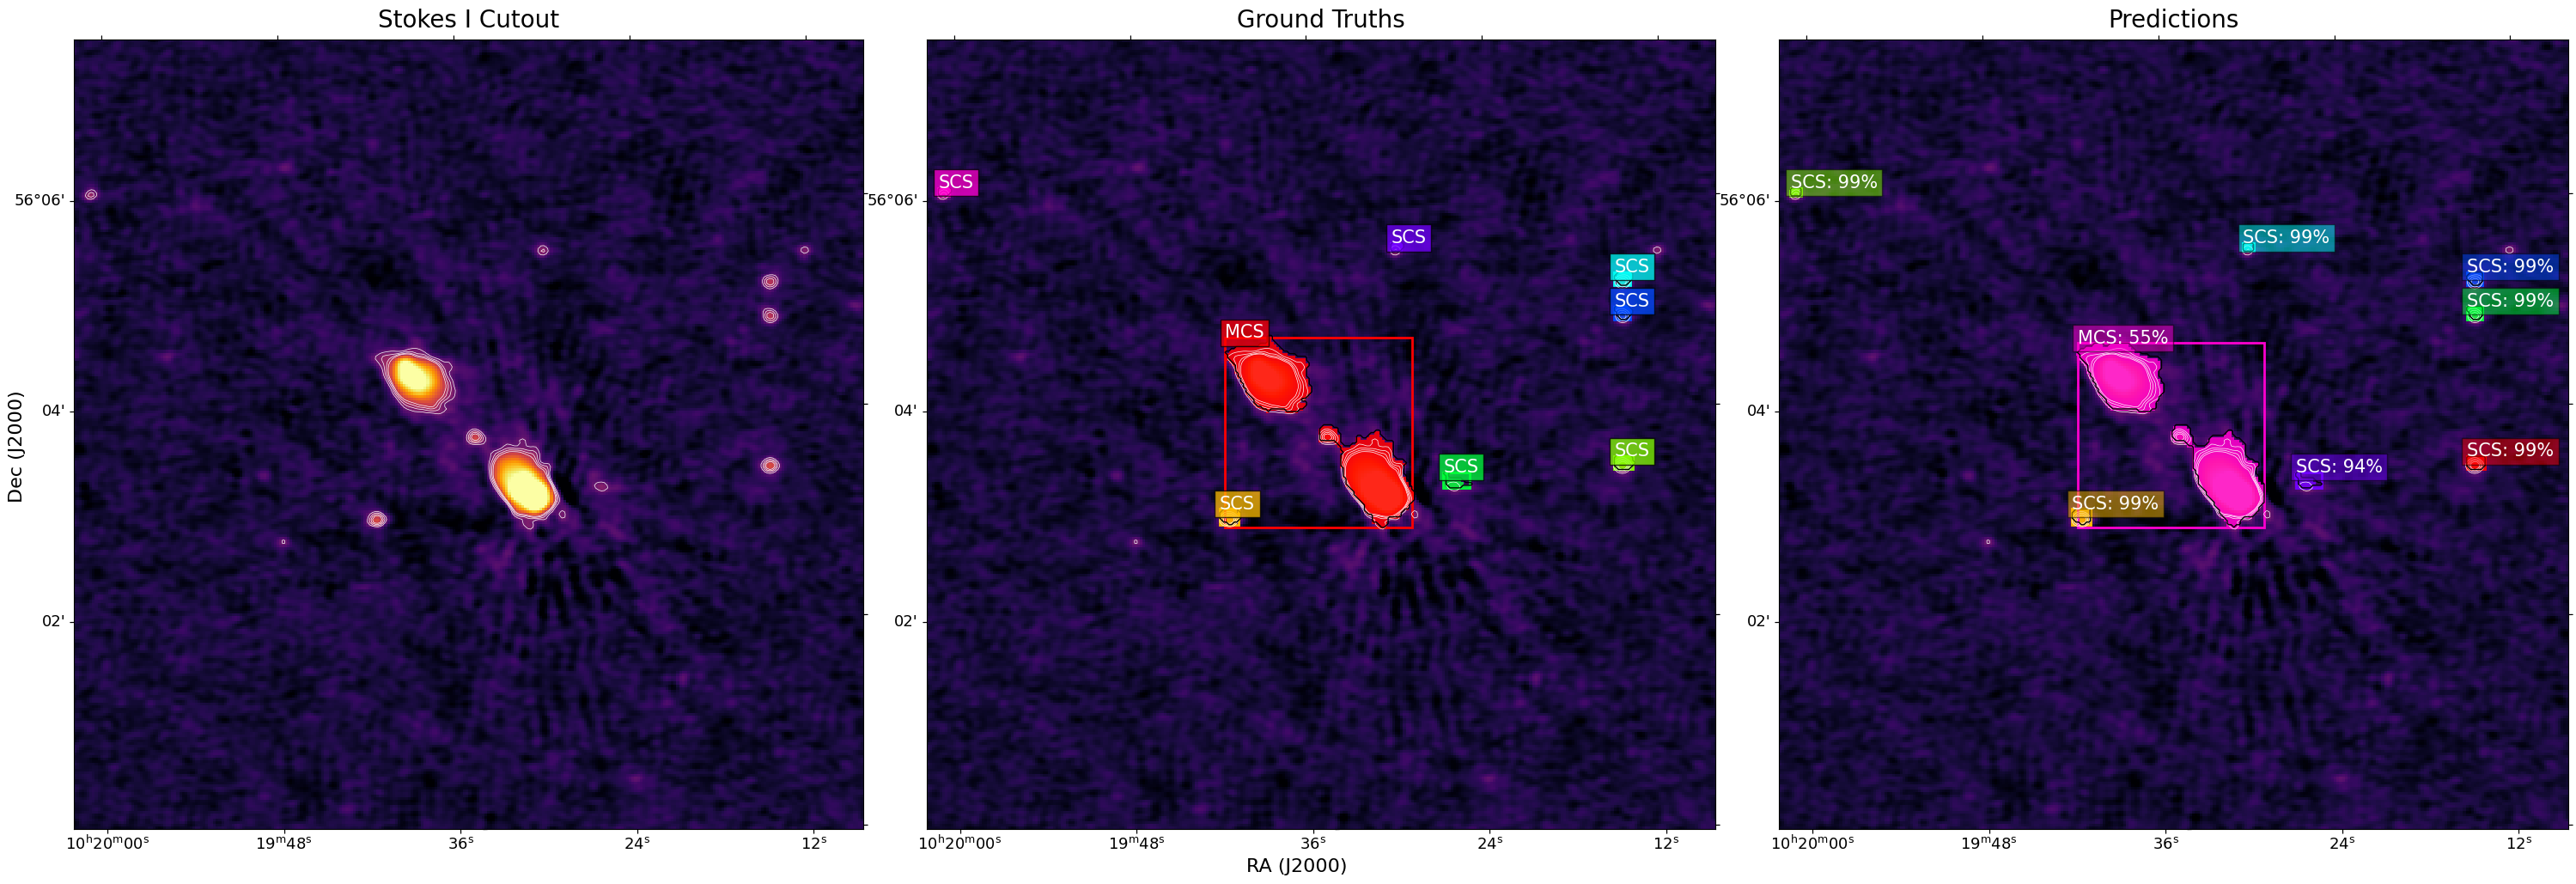

In [28]:
draw_predictions_ontop_of_cutout(cutout, data["294850"]) # 294850

Figure saved to /home/penchev/astro-datatools/data/cutouts_with_predictions2.png


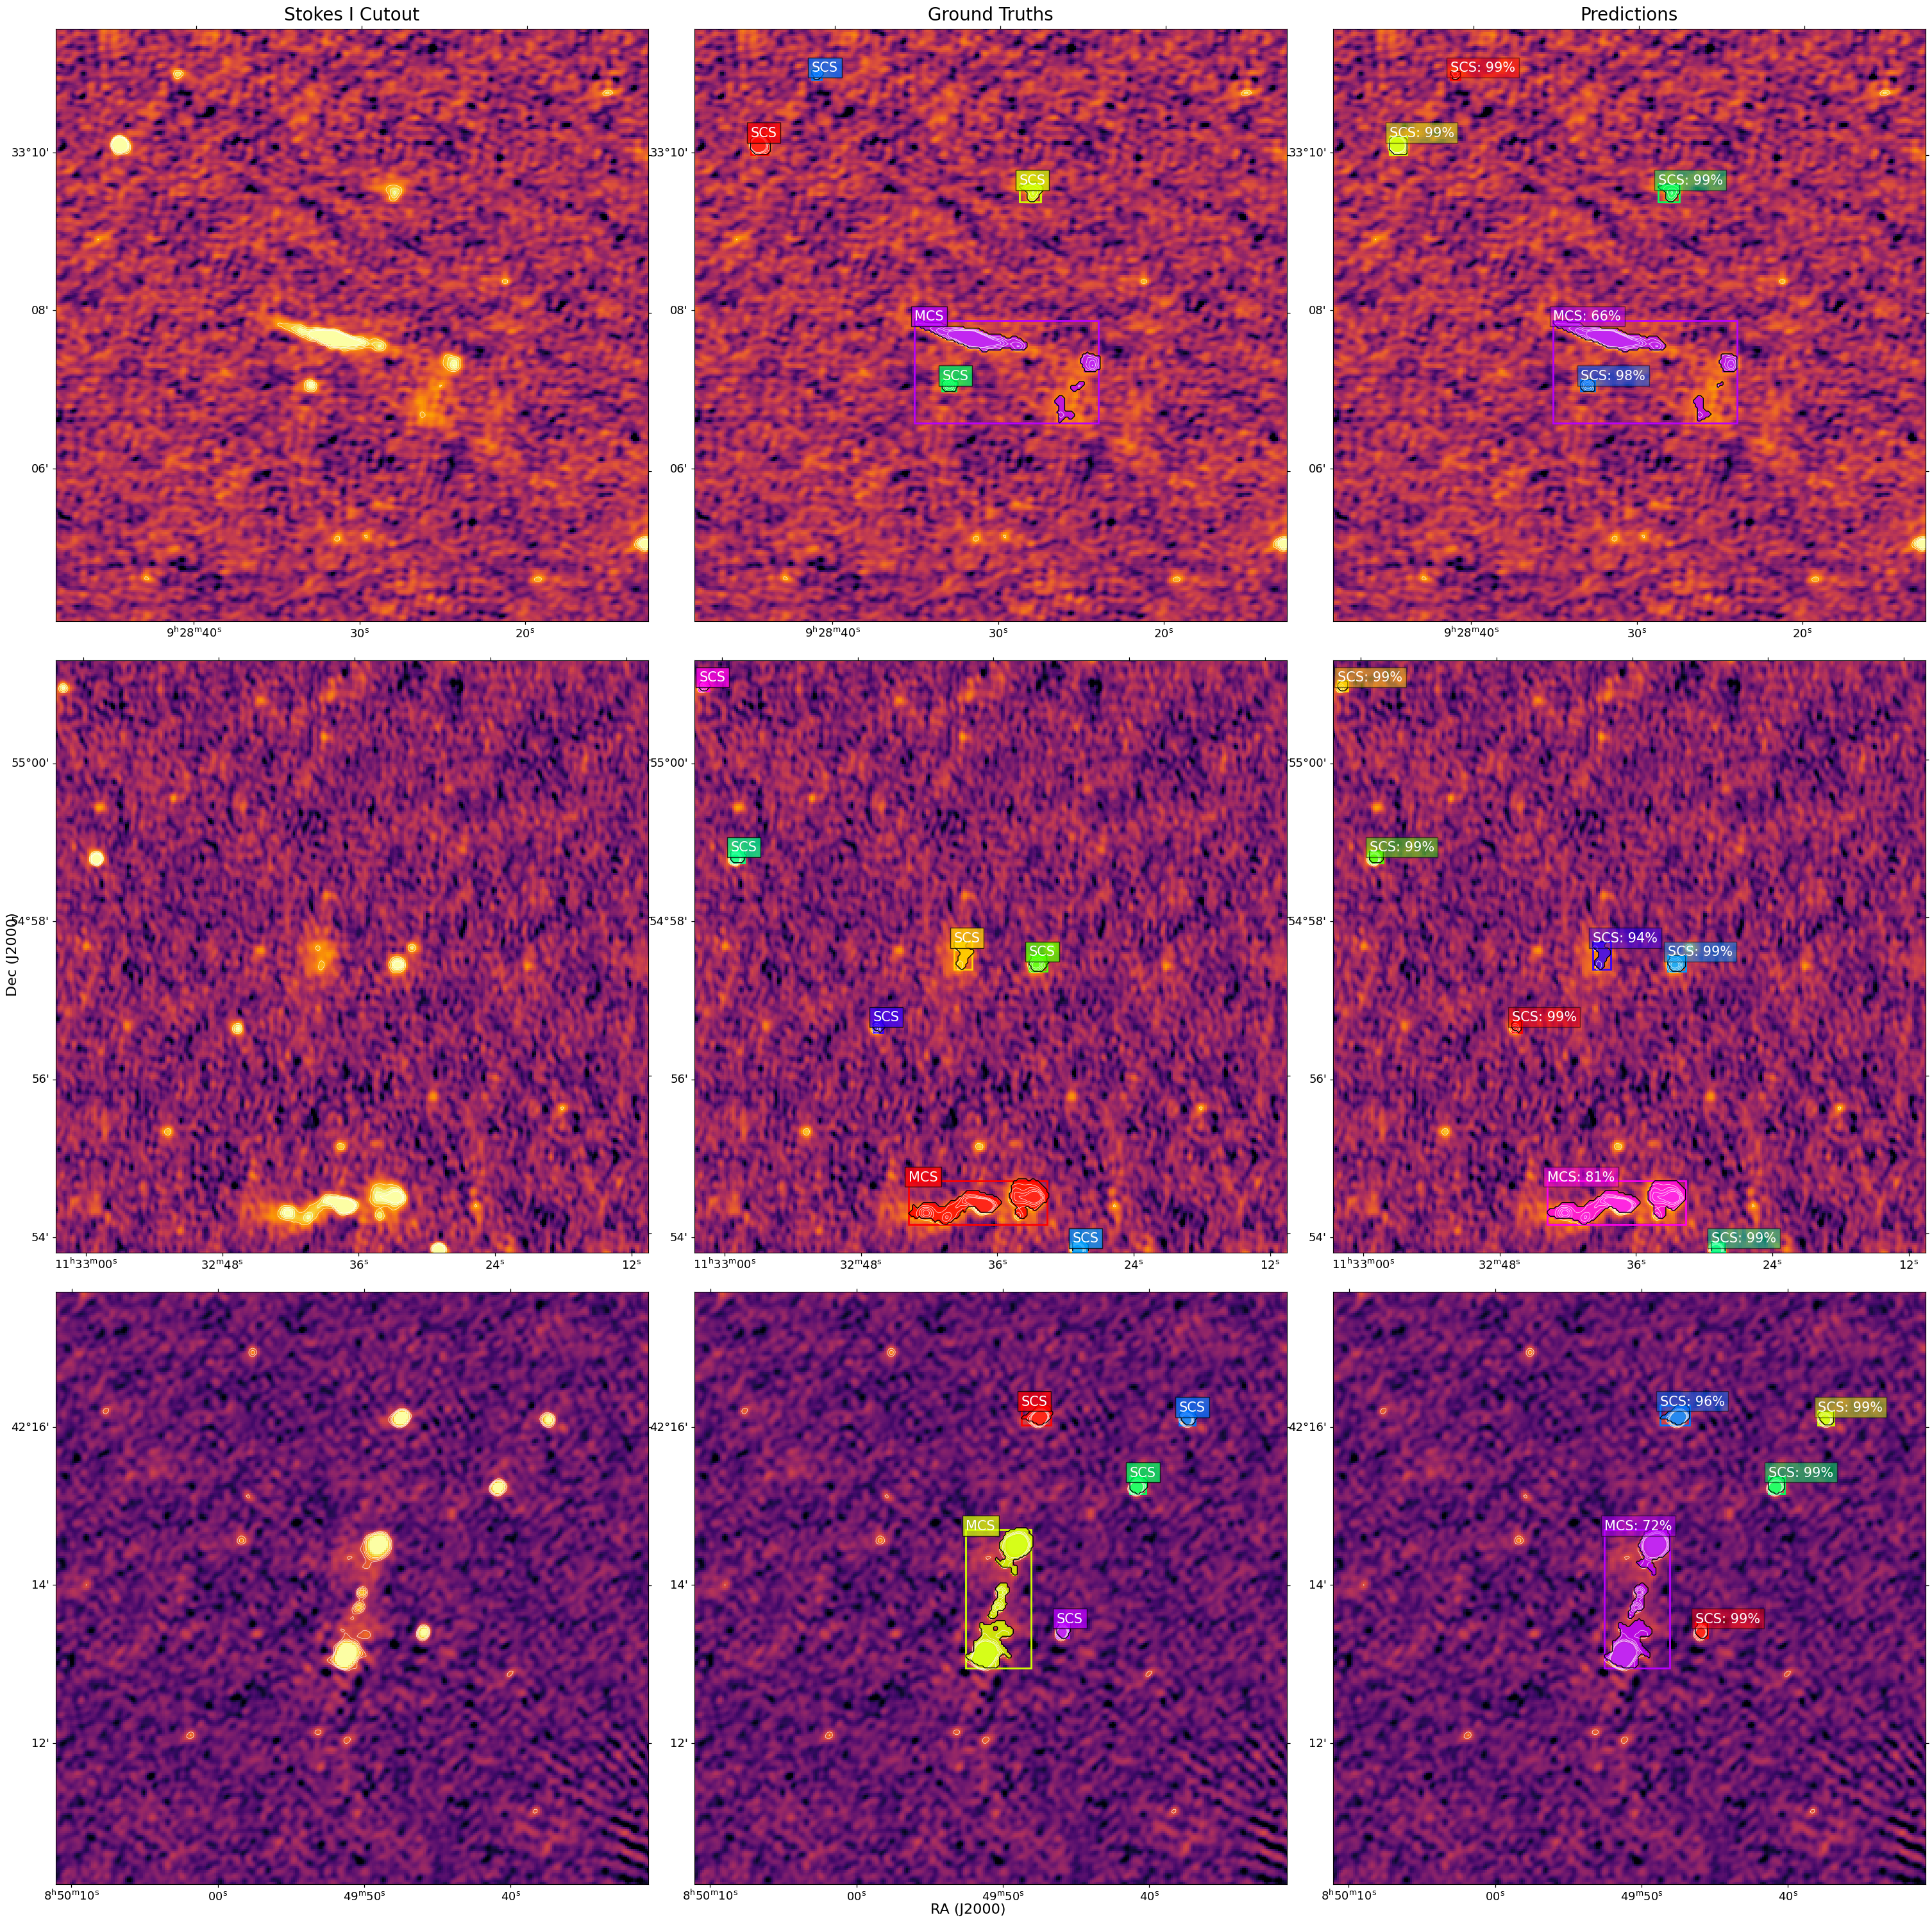

In [24]:
make_3x3_grid_of_cutouts_with_predictions([data["227556"], data["368793"], data["185419"]], name="cutouts_with_predictions2") #255664 225703